<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/NLP/seq2seq_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Subset,DataLoader,random_split
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

# Layer Architecture

In [ ]:
class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(LSTM, self).__init__()
    self.H=hidden_size
    self.fc1=nn.Linear(input_size,4*hidden_size, bias=True)
    self.fc2=nn.Linear(hidden_size,4*hidden_size, bias=False)
    self.tanh=nn.Tanh()
    self.sigmoid=nn.Sigmoid()

  def forward(self,x,h_prev,c_prev):
    A=self.fc1(x)+self.fc2(h_prev)

    f=self.sigmoid(A[:,:self.H])
    i=self.sigmoid(A[:,self.H:2*self.H])
    o=self.sigmoid(A[:,2*self.H:3*self.H])
    g=self.tanh(A[:,3*self.H:])

    c=f*c_prev+i*g
    h=o*self.tanh(c)

    return h,c

In [ ]:
class TimeLSTM(nn.Module):
  def __init__(self, input_size,hidden_size, dropout=0.0):
    super(TimeLSTM, self).__init__()
    self.cell=LSTM(input_size, hidden_size)
    self.dropout_layer = nn.Dropout(p=dropout)
    self.hidden_size=hidden_size

    self.h, self.c= None, None

  def forward(self,xs,h0=None,c0=None):
    batch_size,seq_size,_=xs.shape

    if h0 is not None:
        self.h = h0
        self.c = c0 if c0 is not None else xs.new_zeros(batch_size, self.hidden_size)
    elif self.h is None:
        self.h = xs.new_zeros(batch_size, self.hidden_size)
        self.c = xs.new_zeros(batch_size, self.hidden_size)

    ones = xs.new_ones(batch_size, self.hidden_size)
    mask = self.dropout_layer(ones)

    hs=xs.new_zeros(batch_size, seq_size, self.hidden_size)
    for t in range(seq_size):
      h_input = self.h * mask
      self.h, self.c = self.cell(xs[:,t,:],h_input,self.c)
      hs[:,t,:]=self.h
      # c 에서는 mask 쓰면 안 됨

    return hs

  def detach_state(self):
    if self.h is not None:
        self.h = self.h.detach()
        self.c = self.c.detach()

  def reset_state(self):
    self.h, self.c = None, None

In [ ]:
class TimeDropout(nn.Module):
  def __init__(self, dropout=0.0):
    super(TimeDropout, self).__init__()
    self.dropout_layer=nn.Dropout(p=dropout)

  def forward(self,xs):
    batch_size, _, hidden_size = xs.shape
    ones=xs.new_ones(batch_size,1,hidden_size)
    mask=self.dropout_layer(ones)
    return xs*mask

In [ ]:
class TimeEmbedding(nn.Module):
  def __init__(self,vocab_size,embedding_dim):
    super(TimeEmbedding, self).__init__()
    self.embedding=nn.Embedding(vocab_size,embedding_dim)

  def forward(self,idxs):
    return self.embedding(idxs)

In [ ]:
class TimeLinear(nn.Module):
  def __init__(self,input_size,output_size):
    super(TimeLinear, self).__init__()
    self.linear=nn.Linear(input_size,output_size)

  def forward(self,xs):
    return self.linear(xs)

In [ ]:
class TimeCrossEntropy(nn.Module):
  def __init__(self):
    super(TimeCrossEntropy, self).__init__()
    self.CrossEntropy=nn.CrossEntropyLoss(reduction='sum')

  def forward(self, xs, ts):
    batch_size, seq_size, _ = xs.shape
    xs = xs.reshape(batch_size * seq_size, -1)
    ts = ts.reshape(-1)
    return self.CrossEntropy(xs, ts) / batch_size

In [ ]:
class Encoder(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(Encoder, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = TimeLSTM(hidden_size, hidden_size)

  def forward(self, xs):
    xs = self.embedding(xs)
    return self.lstm(xs)

# seq2seq

In [ ]:
class Seq2Seq_Decoder(nn.Module):
  def __init__(self, hidden_size, output_size,dropout=0.0):
    super(Seq2Seq_Decoder, self).__init__()
    self.embedding = nn.Embedding(output_size, hidden_size)
    self.lstm = TimeLSTM(hidden_size*2, hidden_size)
    self.linear = TimeLinear(hidden_size*2, output_size)
    self.dropout1=TimeDropout(dropout)
    self.dropout2=TimeDropout(dropout)

  def forward(self, xs, h):
    N, T = xs.shape
    xs = self.embedding(xs)
    xs = self.dropout1(xs)


    peeky_h = h.unsqueeze(1).expand(N, T, -1)
    xs = torch.cat([xs, peeky_h], dim=2)
    hs = self.lstm(xs, h)


    hs = self.dropout2(hs)
    hs = torch.cat([hs, peeky_h], dim=2)
    return self.linear(hs)

  def reset_state(self):
    for m in self.modules():
      if isinstance(m, TimeLSTM):
          m.reset_state()

  def detach_state(self):
    for m in self.modules():
      if isinstance(m, TimeLSTM):
          m.detach_state()

  def generate(self, h, start_id, max_length):
    self.eval()
    self.reset_state()
    sampled = []
    sample_id = start_id

    for i in range(max_length):
        xs = torch.tensor([[sample_id]]).to(h.device)
        xs = self.embedding(xs)
        xs = self.dropout1(xs)

        peeky_h = h.unsqueeze(1).expand(xs.shape)
        xs = torch.cat([xs, peeky_h], dim=2)

        if i == 0:
            hs = self.lstm(xs, h)
        else:
            hs = self.lstm(xs)

        hs = self.dropout2(hs)
        hs = torch.cat([hs, peeky_h], dim=2)
        score = self.linear(hs)

        sample_id = torch.argmax(score, dim=2).item()
        sampled.append(sample_id)

    self.train()
    return sampled

In [ ]:
class Seq2SeqPeeky(nn.Module):
  def __init__(self, vocab_size, hidden_size, dropout=0.0):
    super(Seq2SeqPeeky, self).__init__()
    self.encoder = Encoder(vocab_size, hidden_size)
    self.decoder = Seq2Seq_Decoder(hidden_size,vocab_size,dropout)
    self.softmax = TimeCrossEntropy()

  def forward(self, xs, ts):
    decoder_xs, targets = ts[:,:-1], ts[:,1:]

    self.encoder.lstm.reset_state()  # 배치마다 인코더 상태 초기화
    encoder_hs = self.encoder(xs)

    h = encoder_hs[:, -1, :]

    decoder_out = self.decoder(decoder_xs, h)
    return self.softmax(decoder_out, targets)

  def reset_state(self):
    for m in self.modules():
      if isinstance(m, Seq2Seq_Decoder):
          m.reset_state()

  def detach_state(self):
    for m in self.modules():
      if isinstance(m, Seq2Seq_Decoder):
          m.detach_state()

  def generate(self, xs, start_id, max_length):
    self.eval()
    self.encoder.lstm.reset_state()
    encoder_hs = self.encoder(xs)
    h = encoder_hs[:, -1, :]

    sampled = self.decoder.generate(h, start_id, max_length)
    self.train()
    return sampled

아직 Architecture 완성 안 함 Claude

# Attention

In [ ]:
class AttentionWeight(nn.Module):
  def __init__(self):
    super(AttentionWeight, self).__init__()
    self.softmax=nn.Softmax(dim=1)

  def forward(self,hs,h):
    s=torch.sum(hs*h.unsqueeze(1),dim=2)
    return self.softmax(s)

In [ ]:
class WeightSum(nn.Module):
  def __init__(self):
    super(WeightSum, self).__init__()

  def forward(self,hs,w):
    return torch.sum(hs*w.unsqueeze(2),dim=1)

In [ ]:
class Attention(nn.Module):
  def __init__(self):
    super(Attention, self).__init__()
    self.weight=AttentionWeight()
    self.weightSum=WeightSum()

  def forward(self,hs,h):
    w=self.weight(hs,h)
    return self.weightSum(hs,w),w

w visualize 해야됨 (claude에 써놓음)

In [ ]:
class TimeAttention(nn.Module):
  def __init__(self):
    super(TimeAttention, self).__init__()
    self.cell = Attention()
    self.collect_weights = False
    self.attention_weights = None

  def forward(self, hs_enc, hs_dec):
    batch_size, seq_size, _ = hs_dec.shape
    out = hs_dec.new_zeros(hs_dec.shape)
    weights = [] if self.collect_weights else None

    for t in range(seq_size):
      c, w = self.cell(hs_enc, hs_dec[:, t, :])
      out[:, t, :] = c
      if self.collect_weights:
        weights.append(w)

    if self.collect_weights:
      self.attention_weights = torch.stack(weights, dim=1).detach()  # (N, T_dec, T_enc)

    return out

In [ ]:
class Attention_Decoder(nn.Module):
  def __init__(self, hidden_size, output_size, dropout=0.0):
    super(Attention_Decoder, self).__init__()
    self.embedding = nn.Embedding(output_size, hidden_size)
    self.lstm = TimeLSTM(hidden_size, hidden_size)
    self.linear = TimeLinear(hidden_size*2, output_size)
    self.dropout1 = TimeDropout(dropout)
    self.dropout2 = TimeDropout(dropout)
    self.attention = TimeAttention()

  def forward(self, xs, enc_hs):
    N, T = xs.shape
    xs = self.embedding(xs)
    xs = self.dropout1(xs)

    h = enc_hs[:, -1]
    dec_hs = self.lstm(xs, h)        # peeky 없이 h0만 넘겨서 초기화
    dec_hs = self.dropout2(dec_hs)

    c = self.attention(enc_hs, dec_hs)
    out = torch.cat([dec_hs, c], dim=2)
    return self.linear(out)

  def reset_state(self):
    for m in self.modules():
      if isinstance(m, TimeLSTM):
          m.reset_state()

  def detach_state(self):
    for m in self.modules():
      if isinstance(m, TimeLSTM):
          m.detach_state()

  def generate(self, enc_hs, start_id, max_length):
    self.eval()
    self.reset_state()
    self.attention.collect_weights = True
    self.attention.attention_weights = None

    sampled = []
    sample_id = start_id
    h = enc_hs[:, -1]

    for i in range(max_length):
        xs = torch.tensor([[sample_id]]).to(h.device)
        xs = self.embedding(xs)
        xs = self.dropout1(xs)

        if i == 0:
            dec_hs = self.lstm(xs, h)
        else:
            dec_hs = self.lstm(xs)

        dec_hs = self.dropout2(dec_hs)
        c = self.attention(enc_hs, dec_hs)
        out = torch.cat([dec_hs, c], dim=2)
        score = self.linear(out)

        sample_id = torch.argmax(score, dim=2).item()
        sampled.append(sample_id)

    self.attention.collect_weights = False
    self.train()
    return sampled

In [ ]:
class Seq2SeqAttention(nn.Module):
  def __init__(self, vocab_size, hidden_size,dropout=0.0):
    super(Seq2SeqAttention, self).__init__()
    self.encoder = Encoder(vocab_size, hidden_size)
    self.decoder = Attention_Decoder(hidden_size,vocab_size,dropout)
    self.softmax = TimeCrossEntropy()

  def forward(self, xs, ts):
    decoder_xs, targets = ts[:,:-1], ts[:,1:]

    self.encoder.lstm.reset_state()  # 배치마다 인코더 상태 초기화
    enc_hs = self.encoder(xs)



    decoder_out = self.decoder(decoder_xs, enc_hs)
    return self.softmax(decoder_out, targets)

  def reset_state(self):
    for m in self.modules():
      if isinstance(m, Attention_Decoder):
          m.reset_state()

  def detach_state(self):
    for m in self.modules():
      if isinstance(m, Attention_Decoder):
          m.detach_state()

  def generate(self, xs, start_id, max_length):
    self.eval()
    self.encoder.lstm.reset_state()
    enc_hs = self.encoder(xs)
    sampled=self.decoder.generate(enc_hs, start_id, max_length)
    self.train()
    return sampled

# Setting

In [ ]:
epochs=50
learning_rate=1e-3
batch_size=128
early_stopping_patience = 5
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
hidden_size=650
dropout=0.3
seq_size=35

# Dataset

In [ ]:
import os
import urllib.request
import numpy as np

# 1. 데이터 다운로드
url = "https://raw.githubusercontent.com/oreilly-japan/deep-learning-from-scratch-2/master/dataset/date.txt"
urllib.request.urlretrieve(url, "date.txt")

# 2. 원본 sequence.py 로직 그대로 이식
char_to_id, id_to_char = {}, {}

def _update_vocab(txt):
    chars = list(txt)
    for char in chars:
        if char not in char_to_id:
            tmp_id = len(char_to_id)
            char_to_id[char] = tmp_id
            id_to_char[tmp_id] = char

def load_data(file_path='date.txt', seed=1984):
    if not os.path.exists(file_path):
        print('No file: %s' % file_path)
        return None

    questions, answers = [], []

    for line in open(file_path, 'r'):
        idx = line.find('_')
        questions.append(line[:idx])
        answers.append(line[idx:-1])

    # vocab 생성
    for i in range(len(questions)):
        q, a = questions[i], answers[i]
        _update_vocab(q)
        _update_vocab(a)

    # numpy array 변환
    x = np.zeros((len(questions), len(questions[0])), dtype=int)
    t = np.zeros((len(questions), len(answers[0])), dtype=int)

    for i, sentence in enumerate(questions):
        x[i] = [char_to_id[c] for c in list(sentence)]
    for i, sentence in enumerate(answers):
        t[i] = [char_to_id[c] for c in list(sentence)]

    # shuffle
    indices = np.arange(len(x))
    if seed is not None:
        np.random.seed(seed)
    np.random.shuffle(indices)
    x = x[indices]
    t = t[indices]

    # 10% validation
    test_split = len(x) - len(x) // 10
    val_split = len(x) - len(x) // 5

    x_train, x_val, x_test = x[:val_split], x[val_split:test_split], x[test_split:]
    t_train, t_val, t_test = t[:val_split], t[val_split:test_split], t[test_split:]

    return (x_train, t_train),(x_val,t_val),(x_test, t_test)

def get_vocab():
    return char_to_id, id_to_char

# 3. 사용
(x_train, t_train),(x_val,t_val),(x_test, t_test) = load_data('date.txt')
char_to_id, id_to_char = get_vocab()

vocab_size=len(char_to_id)

print(x_train.shape, t_train.shape)   # (40000, 29) (40000, 11) 형태
print(x_test.shape, t_test.shape)
print("vocab_size:", vocab_size)

In [ ]:
from torch.utils.data import TensorDataset

x_train_t = torch.tensor(x_train, dtype=torch.long)
t_train_t = torch.tensor(t_train, dtype=torch.long)
x_val_t = torch.tensor(x_val, dtype=torch.long)
t_val_t = torch.tensor(t_val, dtype=torch.long)
x_test_t = torch.tensor(x_test, dtype=torch.long)
t_test_t = torch.tensor(t_test, dtype=torch.long)

train_ds = TensorDataset(x_train_t, t_train_t)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_ds = TensorDataset(x_val_t, t_val_t)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_ds = TensorDataset(x_test_t, t_test_t)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Preset

In [ ]:
models = {
    'Seq2Seq_Peeky': Seq2SeqPeeky(vocab_size,hidden_size,dropout=dropout).to(device),
    'Seq2Seq_Attention': Seq2SeqAttention(vocab_size,hidden_size,dropout=dropout).to(device)
}

optimizers = {name: optim.Adam(model.parameters(),lr=learning_rate) for name, model in models.items()}
schedulers = {name: optim.lr_scheduler.ReduceLROnPlateau(optimizers[name], mode='min', patience=3, factor=0.1) for name in models}
#criterion = nn.CrossEntropyLoss()

In [ ]:
#%%script echo skip
best_losses={name: float('inf') for name in models}
no_improves = {name: 0 for name in models}
start_epoch = 0
stopped = set()
train_loss_lists = {name: [] for name in models}
val_loss_lists = {name: [] for name in models}
test_acc_lists = {name: [] for name in models}

In [ ]:
def eval_accuracy(model, x_test, t_test, char_to_id, id_to_char, device, sample_size=200, seed=None):
    model.eval()
    start_id = char_to_id['_']          # 디코더 시작 토큰
    max_length = t_test.shape[1] - 1    # targets 길이 (10)

    n = len(x_test)
    if sample_size is not None and sample_size < n:
        rng = np.random.RandomState(seed)
        idx = rng.choice(n, sample_size, replace=False)
    else:
        idx = np.arange(n)

    correct = 0
    with torch.no_grad():
        for i in idx:
            x = x_test[i:i+1].to(device)
            guess_ids = model.generate(x, start_id, max_length)
            guess = ''.join(id_to_char[g] for g in guess_ids)
            answer = ''.join(id_to_char[c.item()] for c in t_test[i, 1:])
            if guess == answer:
                correct += 1

    model.train()
    return correct / len(idx)

# Save

In [ ]:
%%script echo skip

start_epoch=epochs

for name, model in models.items():
  path = f'/content/drive/MyDrive/RNN1_{name}.pth'
  if os.path.exists(path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizers[name].load_state_dict(checkpoint['optimizer_state_dict'])
    schedulers[name].load_state_dict(checkpoint['scheduler_state_dict'])
    best_losses[name] = checkpoint['best_loss']
    no_improves[name] = checkpoint['no_improve']
    train_loss_lists[name] = checkpoint['train_loss_list']
    val_loss_lists[name] = checkpoint['val_loss_list']
    test_acc_lists[name] = checkpoint['test_acc_list']
    stopped=checkpoint['stopped']
    start_epoch = min(start_epoch,checkpoint['epoch']+1)
  else:
    print(f'No file: {path}')

# Train

In [ ]:
#%%script echo skip

for epoch in tqdm(range(start_epoch, epochs), desc="Epoch"):

    for name, model in models.items():
        if name in stopped:
            continue

        train_loss = 0.0
        val_loss = 0.0

        model.train()
        for x, t in tqdm(train_loader, desc=f"{name} Iteration", leave=False):
            x, t = x.to(device), t.to(device)

            model.detach_state()
            optimizers[name].zero_grad()
            loss = model(x,t)
            train_loss += loss.item()
            loss.backward()
            optimizers[name].step()

        model.eval()
        model.reset_state()
        with torch.no_grad():
            for x, t in tqdm(val_loader, desc=f"{name} validation", leave=False):
                x, t = x.to(device), t.to(device)
                val_loss += model(x, t).item()

        test_acc = eval_accuracy(model, x_test_t, t_test_t, char_to_id, id_to_char, device, sample_size=200, seed=epoch)
        test_acc_lists[name].append(test_acc)

        model.reset_state()
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        train_loss_lists[name].append(train_loss)
        val_loss_lists[name].append(val_loss)

        schedulers[name].step(val_loss)

        if val_loss < best_losses[name]:
            best_losses[name] = val_loss
            no_improves[name] = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizers[name].state_dict(),
                'scheduler_state_dict': schedulers[name].state_dict(),
                'best_loss': best_losses[name],
                'no_improve': no_improves[name],
                'train_loss_list': train_loss_lists[name],
                'val_loss_list': val_loss_lists[name],
                'stopped': stopped,
                'epoch': epoch
            }, f'/content/drive/MyDrive/RNN1_{name}.pth')
        else:
            no_improves[name] += 1
            if no_improves[name] >= early_stopping_patience:
                print(f"Early Stopping {name} at Epoch {epoch+1}")
                stopped.add(name)
                torch.save({
                    'no_improve': no_improves[name],
                    'stopped': stopped,
                    'epoch': epoch
                }, f'/content/drive/MyDrive/RNN1_{name}.pth')

    print(f'Epoch {epoch+1} | ' + ' | '.join(
        f'{name} Loss: {train_loss_lists[name][-1]:.4f}'
        for name in models if train_loss_lists[name]
    ))

    if len(stopped) == len(models):
        break

# Visualize

In [ ]:
#%%script echo skip

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss_lists['Seq2Seq_Peeky'], color='blue', linestyle='--')
axes[0].plot(val_loss_lists['Seq2Seq_Peeky'],label='Seq2Seq_Peeky' , color='blue', linestyle='-')
axes[0].plot(train_loss_lists['Seq2Seq_Attention'], color='orange', linestyle='--')
axes[0].plot(val_loss_lists['Seq2Seq_Attention'],label='Seq2Seq_Attention' , color='orange', linestyle='-')
axes[0].set_xlim(-0.1,2.0)
axes[0].set_ylim(-0.1,2.0)
axes[0].set_title("Train, Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(test_acc_lists['Seq2Seq_Peeky'],label='Seq2Seq_Peeky', color='blue', linestyle='-')
axes[1].plot(test_acc_lists['Seq2Seq_Attention'],label='Seq2Seq_Attention' ,color='orange', linestyle='-')
axes[1].set_xlim(-0.1,5.0)
axes[1].set_ylim(0.8,1.01)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

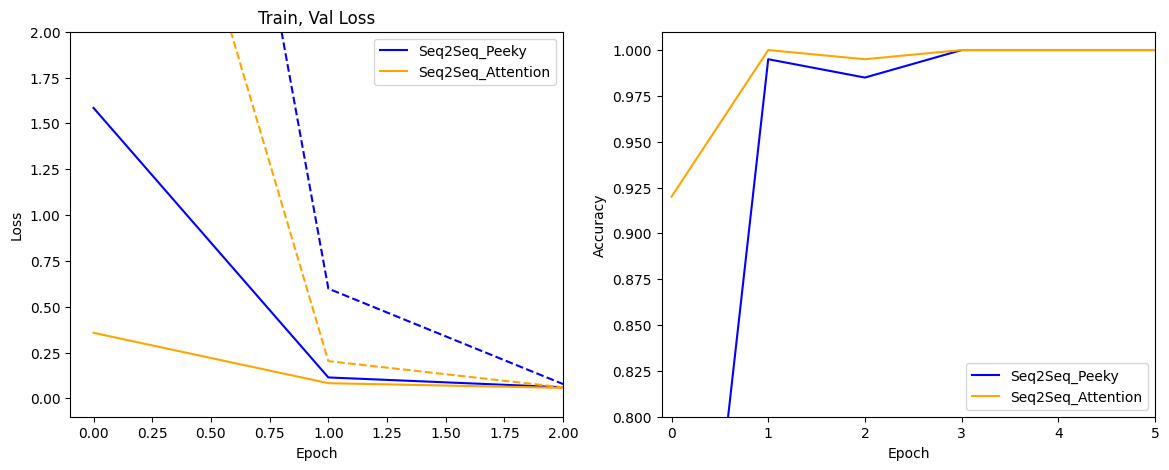

In [ ]:
def visualize(attention_map, row_labels, column_labels):
    fig, ax = plt.subplots()
    ax.pcolor(attention_map, cmap=plt.cm.Greys_r, vmin=0.0, vmax=1.0)
    ax.set_yticks(np.arange(attention_map.shape[0]) + 0.5, minor=False)
    ax.set_xticks(np.arange(attention_map.shape[1]) + 0.5, minor=False)
    ax.invert_yaxis()
    ax.set_xticklabels(row_labels, minor=False)
    ax.set_yticklabels(column_labels, minor=False)
    plt.show()

In [ ]:
models['Seq2Seq_Attention'].eval()
#np.random.seed(1984)

with torch.no_grad():
    for _ in range(5):
        idx = np.random.randint(0, len(x_test_t))

        x = x_test_t[idx:idx+1].to(device)
        t = t_test_t[idx:idx+1].to(device)

        models['Seq2Seq_Attention'].reset_state()
        models['Seq2Seq_Attention'].decoder.attention.collect_weights = True
        models['Seq2Seq_Attention'].forward(x, t)
        models['Seq2Seq_Attention'].decoder.attention.collect_weights = False

        d = models['Seq2Seq_Attention'].decoder.attention.attention_weights
        attention_map = d[0].cpu().numpy()

        x_cpu = x[0].cpu().numpy()
        t_cpu = t[0].cpu().numpy()

        row_labels = [id_to_char[i] for i in x_cpu]
        column_labels = [id_to_char[i] for i in t_cpu[1:]]

        visualize(attention_map, row_labels, column_labels)

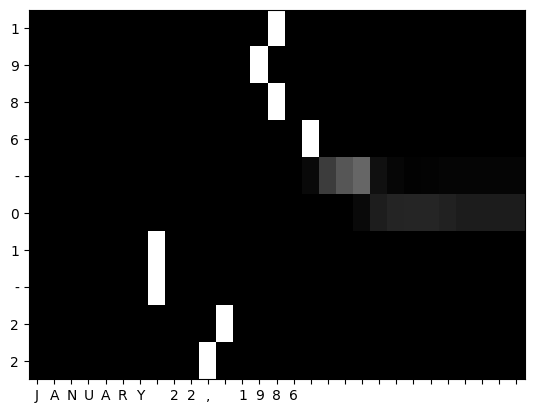

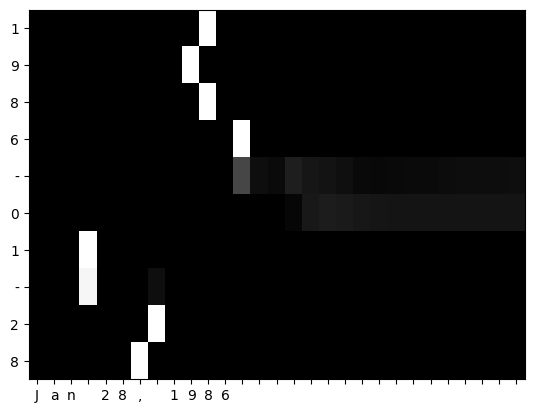

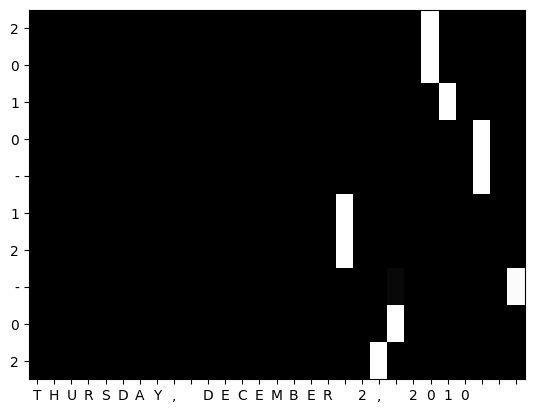

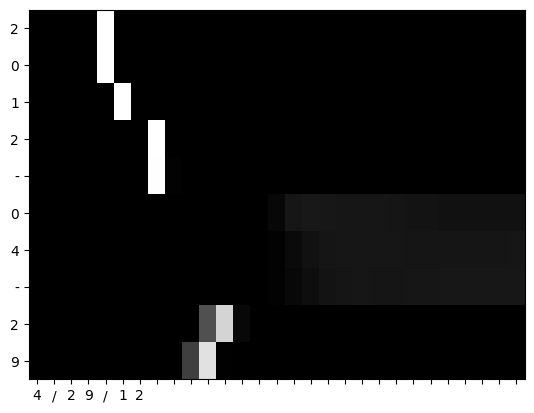

# Generate

In [ ]:
def translate_date(text, model, char_to_id, id_to_char, max_input_len, max_output_len, device):
    model.eval()


    text = text[:max_input_len].ljust(max_input_len)


    unknown = [c for c in text if c not in char_to_id]
    if unknown:
        raise ValueError(f"vocab에 없는 문자가 있어요: {set(unknown)}")


    ids = [char_to_id[c] for c in text]
    x = torch.tensor([ids], dtype=torch.long).to(device)   # (1, max_input_len)


    start_id = char_to_id['_']
    with torch.no_grad():
        sampled_ids = model.generate(x, start_id, max_output_len)


    result = ''.join(id_to_char[i] for i in sampled_ids)

    model.train()
    return result

In [ ]:
max_input_len = x_train.shape[1]     # 29
max_output_len = t_train.shape[1] - 1  # 10 (시작 토큰 '_' 제외)

text = input("날짜를 입력하세요 (예: september 27, 1994): ")
result = translate_date(text, models['Seq2Seq_Attention'], char_to_id, id_to_char,
                         max_input_len, max_output_len, device)
print(f"입력: {text}")
print(f"변환: {result}")

날짜를 입력하세요 (예: september 27, 1994): 3/8/87
입력: 3/8/87
변환: 1987-03-08